In [ ]:
# KANs regression model script for predicting fermi
import time
import os
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
!pip install pykan
from kan import KAN

In [ ]:
# configuration
batch_size = 32
num_epochs = 300
train_losses = []
val_losses = []


seed = 43
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# loading data
data = pd.read_csv("/content/CNT_Chiral_Index.csv")

df_0 = data[data["Metal (1) or Semi (0)"] == 0]
df_1 = data[data["Metal (1) or Semi (0)"] == 1]

# undersample class 1 to match class 0 size
df_0_under = df_0.sample(len(df_1), random_state=seed)

# balanced dataset
data = pd.concat([df_1, df_0_under]).sample(frac=1, random_state=seed)

# selecting features and target
features = ["n", "m", "diameter (A)", "chiral angle (deg.)"]
target = "peakposition from Fermi level (eV)"

X = data[features].values.astype(np.float32)
y = data[target].values.astype(np.float32).reshape(-1,1)

In [ ]:
# train test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=seed
)

In [ ]:
# building data loaders
x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
x_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(x_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

# define KANs model
model = KAN(width=[4, 5, 1], grid=5, k=3, seed=seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=1e-3,
                       weight_decay=1e-4)

checkpoint directory created: ./model
saving model version 0.0
using device: cuda


In [ ]:
# training
# starting training time
print("\nstarting training...")
start_time = time.time()


for epoch in range(num_epochs):
  model.train()
  epoch_losses = []

  for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device)

    optimizer.zero_grad()
    preds = model(xb)
    loss = criterion(preds, yb)
    loss.backward()
    optimizer.step()

    epoch_losses.append(loss.item())

  # computing mean loss for each epoch
  epoch_loss = sum(epoch_losses) / len(epoch_losses)

  # saving for plotting
  train_losses.append(epoch_loss)

  # validation step
  model.eval()
  val_epoch_losses = []
  with torch.no_grad():
    for xb_val, yb_val in test_loader:
      xb_val, yb_val = xb_val.to(device), yb_val.to(device)
      val_preds = model(xb_val)
      val_loss = criterion(val_preds, yb_val)
      val_epoch_losses.append(val_loss.item())

  val_epoch_loss = sum(val_epoch_losses) / len(val_epoch_losses)
  val_losses.append(val_epoch_loss)


  if (epoch + 1) % 10 == 0:
    print(f"epoch {epoch + 1}/{num_epochs}, train mse loss = {epoch_loss: .6f}, val mse loss = {val_epoch_loss: .6f}")

# ending training time
train_end = time.time()
train_time = train_end - start_time
print(f"\ntraining finished in {train_time:.1f} seconds")


starting training...
epoch 10/300, train mse loss =  1.972799, val mse loss =  1.467419
epoch 20/300, train mse loss =  0.960337, val mse loss =  0.749750
epoch 30/300, train mse loss =  0.510291, val mse loss =  0.387701
epoch 40/300, train mse loss =  0.314586, val mse loss =  0.220490
epoch 50/300, train mse loss =  0.232261, val mse loss =  0.173315
epoch 60/300, train mse loss =  0.192634, val mse loss =  0.149960
epoch 70/300, train mse loss =  0.162811, val mse loss =  0.132841
epoch 80/300, train mse loss =  0.141011, val mse loss =  0.119962
epoch 90/300, train mse loss =  0.122800, val mse loss =  0.104753
epoch 100/300, train mse loss =  0.108612, val mse loss =  0.090828
epoch 110/300, train mse loss =  0.095201, val mse loss =  0.079416
epoch 120/300, train mse loss =  0.085094, val mse loss =  0.069134
epoch 130/300, train mse loss =  0.077201, val mse loss =  0.061852
epoch 140/300, train mse loss =  0.071792, val mse loss =  0.058588
epoch 150/300, train mse loss =  0.

In [ ]:
# evaluation
model.eval()

with torch.no_grad():
  y_pred = model(x_test_tensor.to(device)).cpu().numpy()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("test performance")
print(f"mse: {mse:.6f}")
print(f"mae: {mae:.6f}")
print(f"r2 score: {r2:.6f}")


train_end = time.time()
train_time = train_end - start_time
total_time = train_end - start_time

# time summary
print("\ntime summary")
print(f"training time:        {train_time:.1f} seconds")
print(f"total runtime:         {total_time:.1f} seconds")
print(f"total train + start time: {total_time:.1f} seconds")

test performance
mse: 0.055937
mae: 0.172271
r2 score: 0.695797

time summary
training time:        410.6 seconds
total runtime:         410.6 seconds
total train + start time: 410.6 seconds


In [ ]:
residuals = y_test - y_pred

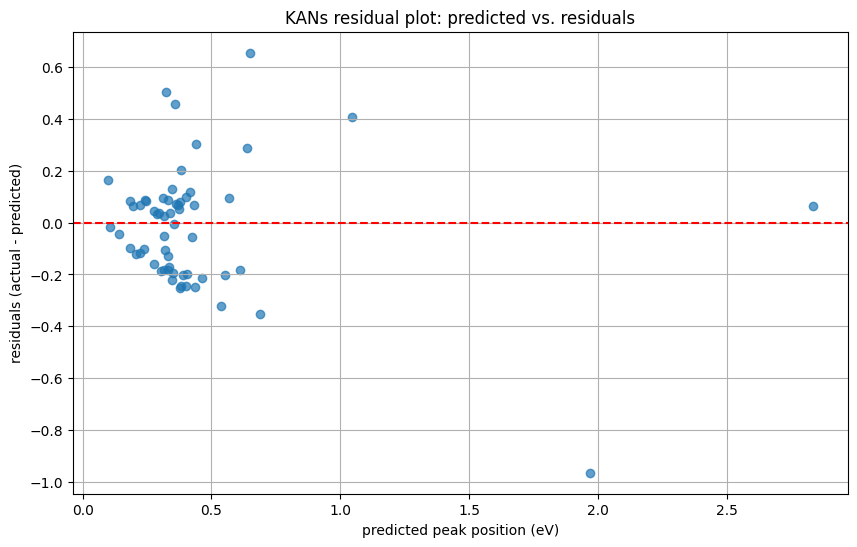

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('predicted peak position (eV)')
plt.ylabel('residuals (actual - predicted)')
plt.title('KANs residual plot: predicted vs. residuals')
plt.grid(True)
plt.savefig('residual_plot.png')
plt.show()

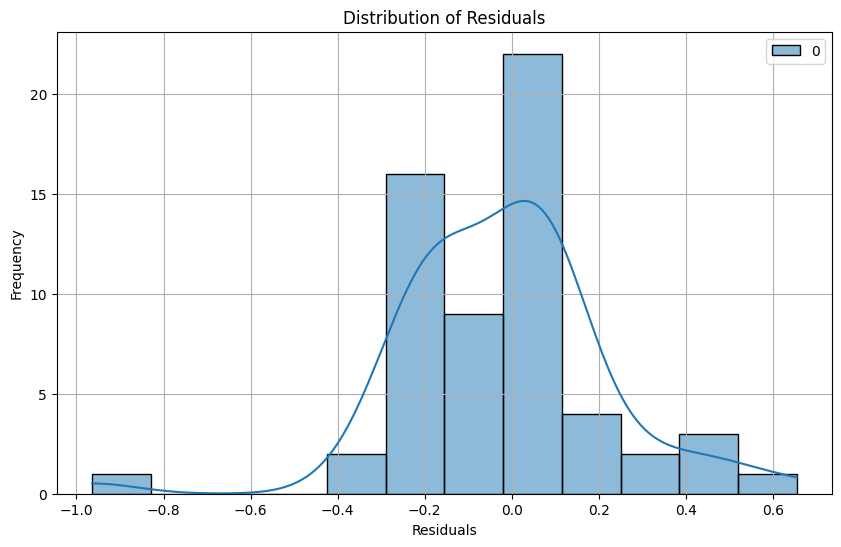

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('residuals')
plt.ylabel('frequency')
plt.title('KANs distribution of residuals')
plt.grid(True)
plt.savefig('residuals_distribution.png')
plt.show()

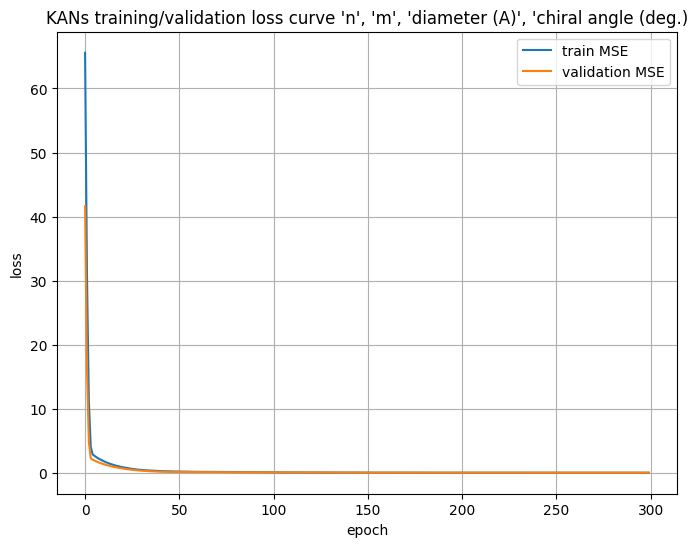

In [ ]:
# plotting training loss curve
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="train MSE") # plot train losses
plt.plot(val_losses, label="validation MSE") # plot validation losses

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("KANs training/validation loss curve 'n', 'm', 'diameter (A)', 'chiral angle (deg.)") # update title
plt.savefig('val_curve')
plt.grid(True)
plt.legend()
plt.show()

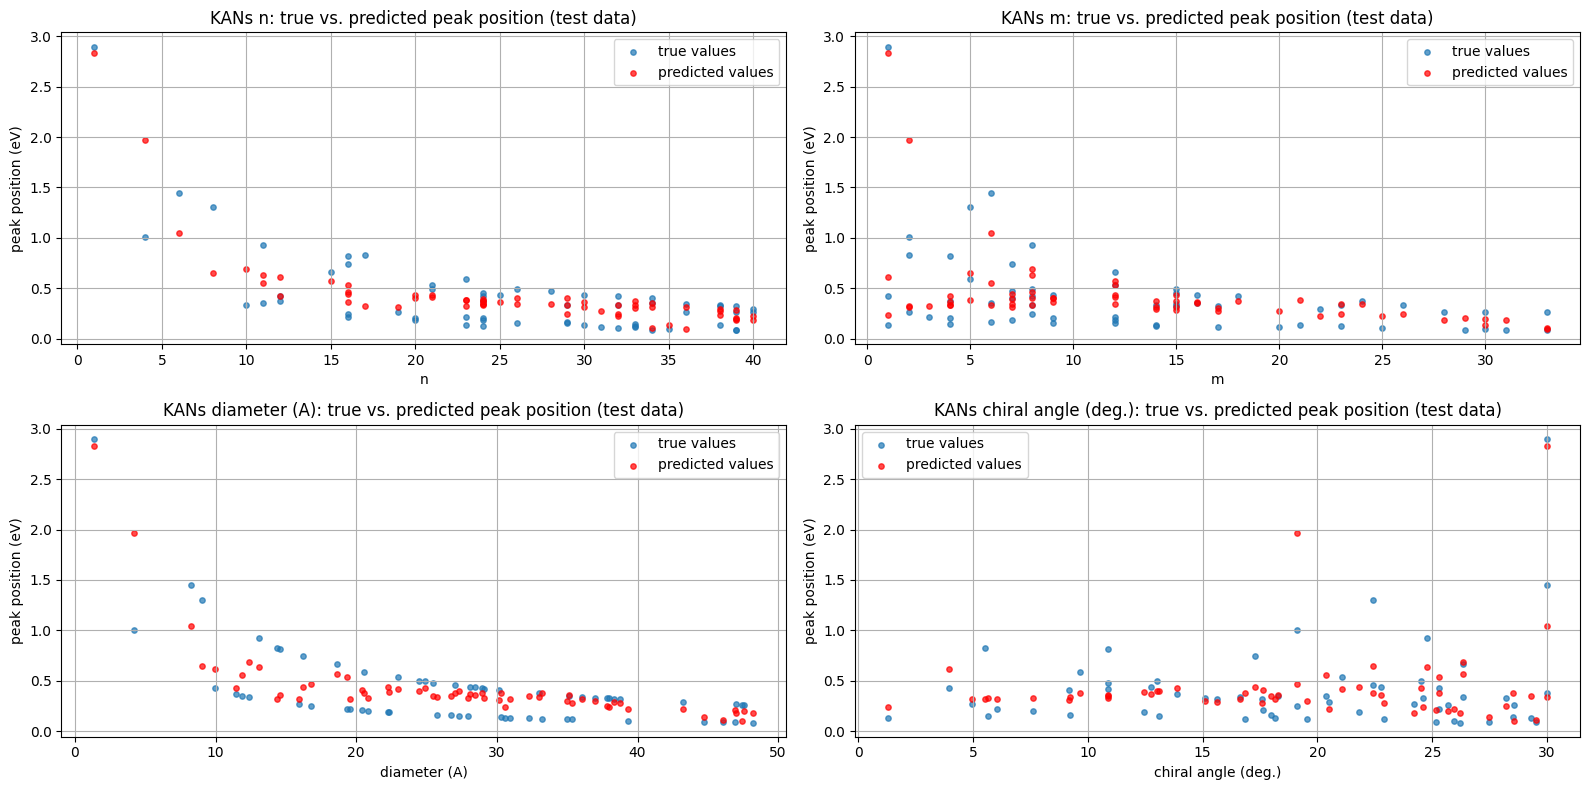

In [ ]:
num_features = len(features)
plt.figure(figsize=(16, 4 * ((num_features + 1) // 2))) # adjust figure height dynamically

for i, feature_name in enumerate(features):
    plt.subplot((num_features + 1) // 2, 2, i + 1) # create 2 columns for subplots
    plt.scatter(X_test[:, i], y_test, s=15, alpha=0.7, label='true values')
    plt.scatter(X_test[:, i], y_pred, s=15, alpha=0.7, color='red', label='predicted values')
    plt.xlabel(feature_name)
    plt.ylabel('peak position (eV)')
    plt.title(f'KANs {feature_name}: true vs. predicted peak position (test data)')
    plt.grid(True)
    plt.legend()

plt.savefig('features_scatter_plot')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

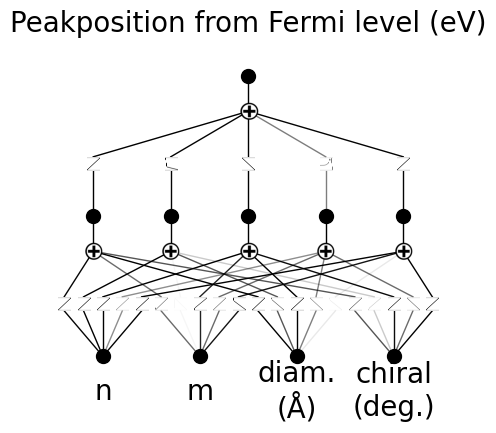

In [ ]:
plt.figure(figsize=(8, 6))

model.plot(
    folder=kan_plot_folder,
    in_vars=[
        'n',
        'm',
        'diam.\n(Å)',
        'chiral\n(deg.)'
    ],
    out_vars=['Peakposition from Fermi level (eV)']
)

plt.savefig('kans_bsplines')